In [15]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.optimize import curve_fit

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.distribution_functions.sampling import sample_df_potential
from phoenix.distribution_functions.disk import f_disc_from_params
from phoenix.distribution_functions.spheroid import f_double_power_law
from phoenix.potentials.potentials import nfw_potential, miyamoto_nagai_potential, plummer_potential

# 1. SETUP POTENTIAL & DF PARAMETERS

In [16]:
# Physical parameters for the potential (Masses in M_sun, Distances in kpc)
M_halo = 1e12
a_halo = 20.0
M_disk = 5e10
a_disk = 3.0
b_disk = 0.3
M_bulge = 1e10 
a_bulge = 1.0

def total_potential(x, y, z):
    """Combined gravitational potential (Halo + Disk + Bulge)."""
    phi_halo = nfw_potential(x, y, z, M_halo, a_halo)
    phi_disk = miyamoto_nagai_potential(x, y, z, M_disk, a_disk, b_disk)
    phi_bulge = plummer_potential(x, y, z, M_bulge, a_bulge)
    return phi_halo + phi_disk + phi_bulge

# Parameters for the Quasi-Isothermal Disk DF
disk_df_params = {
    "R0": 8.0, "Rd": 3.0, "Sigma0": 1000.0,
    "RsigR": 6.0, "RsigZ": 6.0,
    "sigmaR0_R0": 35.0, "sigmaz0_R0": 20.0,
    "L0": 10.0, "Rinit_for_Rc": 8.0
}

# Parameters for the Double Power-Law Spheroid DF
bulge_df_params = {
    "N0_spheroid": 1e10, "J0_spheroid": 100.0,
    "Gamma_spheroid": 1.5, "Beta_spheroid": 4.5, "eta_spheroid": 1.0
}

# Parameters required by the Phoenix Neural Network (Masses scaled by 1e11)
nn_potential_params = np.array([
    M_halo / 1e11, a_halo,
    M_disk / 1e11, a_disk, b_disk,
    M_bulge / 1e11, a_bulge
])

def spheroid_df_wrapper(Jr, Jz, Jphi, Phi_xyz, theta, params):
    return f_double_power_law(Jr, Jz, Jphi, params)


# 2. DIFFERENTIABLE SAMPLING (DISK + BULGE)

In [17]:
print("Starting differentiable action sampling for multiple components...")
N_disk_samples = 100_000
N_bulge_samples = 50_000
key = jax.random.PRNGKey(42)

Starting differentiable action sampling for multiple components...


In [18]:
# --- A. Sample the Disk ---
print(" -> Sampling Disk...")
test_disk = f_disc_from_params(10.0, 5.0, 2000.0, total_potential, (), disk_df_params)
env_max_disk = float(test_disk) * 2.0 

key, subkey = jax.random.split(key)
cand_disk, w_disk = sample_df_potential(
    df=f_disc_from_params, key=subkey, params=disk_df_params, Phi_xyz=total_potential,
    theta=(), n_candidates=N_disk_samples, envelope_max=env_max_disk, 
    J_bounds=(100.0, 50.0, 3000.0), tau=0.05
)
key, subkey = jax.random.split(key)
angles_disk = jax.random.uniform(subkey, shape=(N_disk_samples, 3), minval=0.0, maxval=2*jnp.pi)


 -> Sampling Disk...


In [19]:
# --- B. Sample the Bulge ---
print(" -> Sampling Bulge...")
test_bulge = spheroid_df_wrapper(10.0, 10.0, 10.0, total_potential, (), bulge_df_params)
env_max_bulge = float(test_bulge) * 2.0 

key, subkey = jax.random.split(key)
cand_bulge, w_bulge = sample_df_potential(
    df=spheroid_df_wrapper, key=subkey, params=bulge_df_params, Phi_xyz=total_potential,
    theta=(), n_candidates=N_bulge_samples, envelope_max=env_max_bulge, 
    J_bounds=(500.0, 500.0, 500.0), tau=0.05
)
key, subkey = jax.random.split(key)
angles_bulge = jax.random.uniform(subkey, shape=(N_bulge_samples, 3), minval=0.0, maxval=2*jnp.pi)


 -> Sampling Bulge...


In [20]:
# Fix net rotation for the bulge (50% positive Lz, 50% negative Lz)
cand_bulge_np = np.array(cand_bulge)
#flip_mask = np.random.choice([-1.0, 1.0], size=N_bulge_samples)
#cand_bulge_np[:, 2] = cand_bulge_np[:, 2] * flip_mask

In [21]:
# --- C. Combine and Scale Weights ---
print(" -> Combining components and scaling physical masses...")
# CRITICAL: We must scale the soft weights so their sum equals the physical mass of the component!
w_disk_scaled = np.array(w_disk) / np.sum(w_disk) * M_disk
w_bulge_scaled = np.array(w_bulge) / np.sum(w_bulge) * M_bulge

all_candidates = np.vstack([np.array(cand_disk), cand_bulge_np])
all_angles = np.vstack([np.array(angles_disk), np.array(angles_bulge)])
all_weights = np.concatenate([w_disk_scaled, w_bulge_scaled])

 -> Combining components and scaling physical masses...


# 3. MAPPING ACTIONS TO PHASE SPACE

In [22]:
print("Mapping combined actions to phase space using Phoenix Surrogate...")
mapper = PhoenixMapper()

total_samples = N_disk_samples + N_bulge_samples
potentials_batch = np.tile(nn_potential_params, (total_samples, 1))

# Execute the Neural Network Mapping
phase_space = mapper.map_to_phase_space(all_candidates, all_angles, potentials_batch)
x, y, z = phase_space[:, 0], phase_space[:, 1], phase_space[:, 2]
vx, vy, vz = phase_space[:, 3], phase_space[:, 4], phase_space[:, 5]

Mapping combined actions to phase space using Phoenix Surrogate...
Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz
Model loaded and ready for inference!


In [23]:
# NEW: Fix Bulge Rotation AFTER the network mapping by exploiting physical symmetry!
# Reflecting y and vy for 50% of the bulge stars perfectly flips their Lz to retrograde
# without forcing the neural network to extrapolate into unknown negative Lz territory.
bulge_flip_mask = np.random.choice([1.0, -1.0], size=N_bulge_samples)
y[N_disk_samples:] *= bulge_flip_mask
vy[N_disk_samples:] *= bulge_flip_mask

# 4. PLOTTING SPATIAL PLANES

Generating Spatial Density plots...


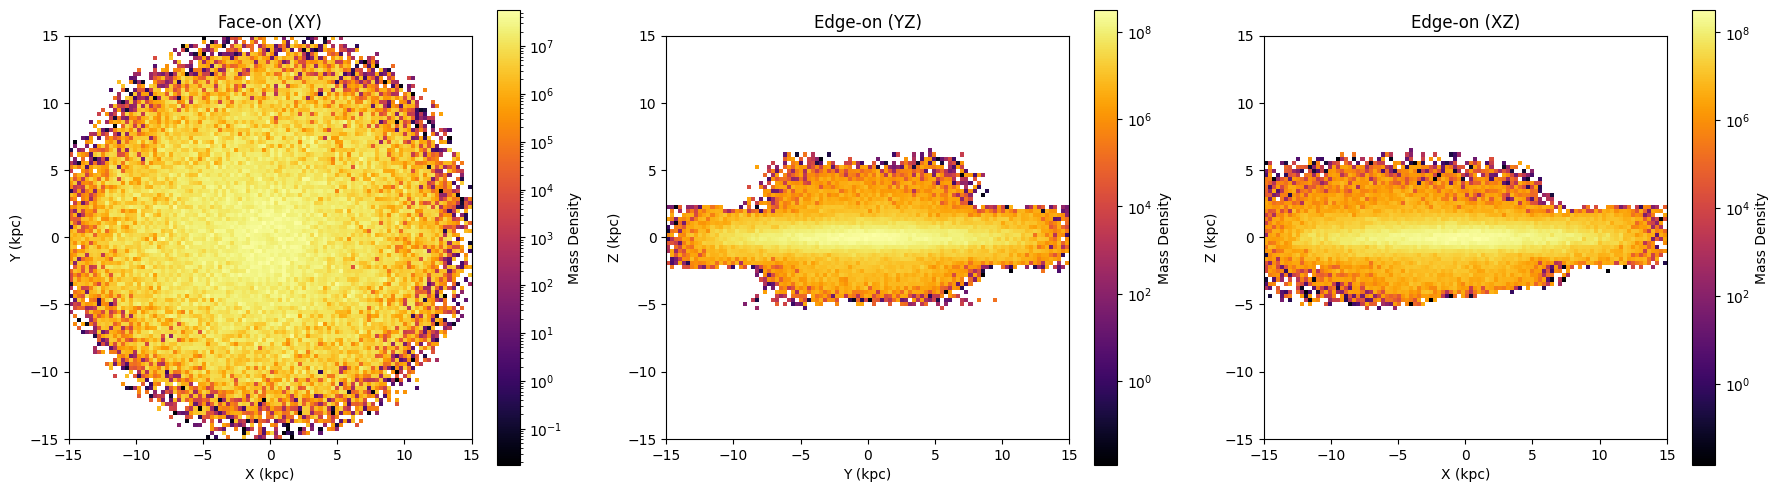

In [24]:
print("Generating Spatial Density plots...")
fig_space, axes_space = plt.subplots(1, 3, figsize=(18, 5))

# We use hist2d with 'all_weights' to apply the correctly scaled mass distributions!
planes = [(x, y, 'X (kpc)', 'Y (kpc)', 'Face-on (XY)'),
          (y, z, 'Y (kpc)', 'Z (kpc)', 'Edge-on (YZ)'),
          (x, z, 'X (kpc)', 'Z (kpc)', 'Edge-on (XZ)')]

for i, (coord1, coord2, xlabel, ylabel, title) in enumerate(planes):
    ax = axes_space[i]
    h = ax.hist2d(coord1, coord2, bins=100, range=[[-15, 15], [-15, 15]], 
                  weights=all_weights, cmap='inferno', norm=LogNorm())
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_aspect('equal')
    fig_space.colorbar(h[3], ax=ax, label='Mass Density')

plt.tight_layout()
plt.show()

# 5. GAUSS-HERMITE LINE-OF-SIGHT KINEMATICS

In [25]:
print("Generating Gauss-Hermite Kinematic maps...")

def gauss_hermite(v, v_rot, v_disp, h3, h4):
    y = np.asarray((np.asarray(v) - v_rot) / (v_disp))
    return (np.exp(-0.5 * y**2)/(v_disp*np.sqrt(2*np.pi)) )* (
        1 + h3 * ((2 * np.sqrt(2) * y**3 - 3 * np.sqrt(2) * y) / np.sqrt(6))
          + h4 * ((4 * y**4 - 12 * y**2 + 3) / np.sqrt(24))
    )

def fit_losvd_weighted(v_bin, w_bin):
    if len(v_bin) < 10 or np.sum(w_bin) < 1.0:
        return np.nan, np.nan, np.nan, np.nan
        
    hist, bins = np.histogram(v_bin, bins=30, density=True, weights=w_bin)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    V_guess = np.average(v_bin, weights=w_bin)
    variance = np.average((v_bin - V_guess)**2, weights=w_bin)
    sigma_guess = np.sqrt(variance)
    
    if sigma_guess == 0:
        return V_guess, 0.0, 0.0, 0.0
        
    p0 = [V_guess, sigma_guess, 0.1, 0.1]
    try:
        popt, _ = curve_fit(gauss_hermite, bin_centers, hist, p0=p0, maxfev=10000)
    except (RuntimeError, ValueError, TypeError):
        return np.nan, np.nan, np.nan, np.nan
    return popt

def compute_kinematic_maps(c1, c2, v_los, weights_arr, bins1, bins2):
    grid1, grid2 = len(bins1) - 1, len(bins2) - 1
    V_map = np.zeros((grid2, grid1)); sigma_map = np.zeros((grid2, grid1))
    h3_map = np.zeros((grid2, grid1)); h4_map = np.zeros((grid2, grid1))

    for i in range(grid1):
        for j in range(grid2):
            mask = (c1 >= bins1[i]) & (c1 < bins1[i+1]) & (c2 >= bins2[j]) & (c2 < bins2[j+1])
            w_bin = weights_arr[mask]
            
            if np.sum(w_bin) < 1.0 or len(v_los[mask]) < 10: 
                V_map[j, i] = np.nan; sigma_map[j, i] = np.nan
                h3_map[j, i] = np.nan; h4_map[j, i] = np.nan
                continue
                
            v_rot, v_disp, h3, h4 = fit_losvd_weighted(v_los[mask], w_bin)
            V_map[j, i] = v_rot; sigma_map[j, i] = v_disp
            h3_map[j, i] = h3; h4_map[j, i] = h4
            
    return V_map, sigma_map, h3_map, h4_map

def plot_kinematic_grid(V, sigma, h3, h4, extent, xlabel, ylabel, title, v_range, sig_range):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(title, fontsize=16)
    axes = axes.flatten()

    maps = [
        (V, 'LOS Velocity ($V$)', 'coolwarm', -v_range, v_range),
        (sigma, 'Dispersion ($\sigma$)', 'viridis', 0, sig_range),
        (h3, 'GH $h_3$ (Asymmetry)', 'PiYG', -0.15, 0.15),
        (h4, 'GH $h_4$ (Tails)', 'PuOr', -0.15, 0.15)
    ]

    for i, (data, m_title, cmap, vmin, vmax) in enumerate(maps):
        ax = axes[i]
        im = ax.imshow(data, origin='lower', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_title(m_title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# KINEMATICS MAPPING
# ------------------------------------------------------------------------------
grid_size = 30
x_bins = np.linspace(-15, 15, grid_size + 1)
y_bins = np.linspace(-15, 15, grid_size + 1)
z_bins = np.linspace(-5, 5, grid_size + 1)

Generating Gauss-Hermite Kinematic maps...


<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_851358/4153009935.py:59: SyntaxWarning: invalid escape sequence '\s'
  (sigma, 'Dispersion ($\sigma$)', 'viridis', 0, sig_range),


Computing Edge-On (XZ) maps...


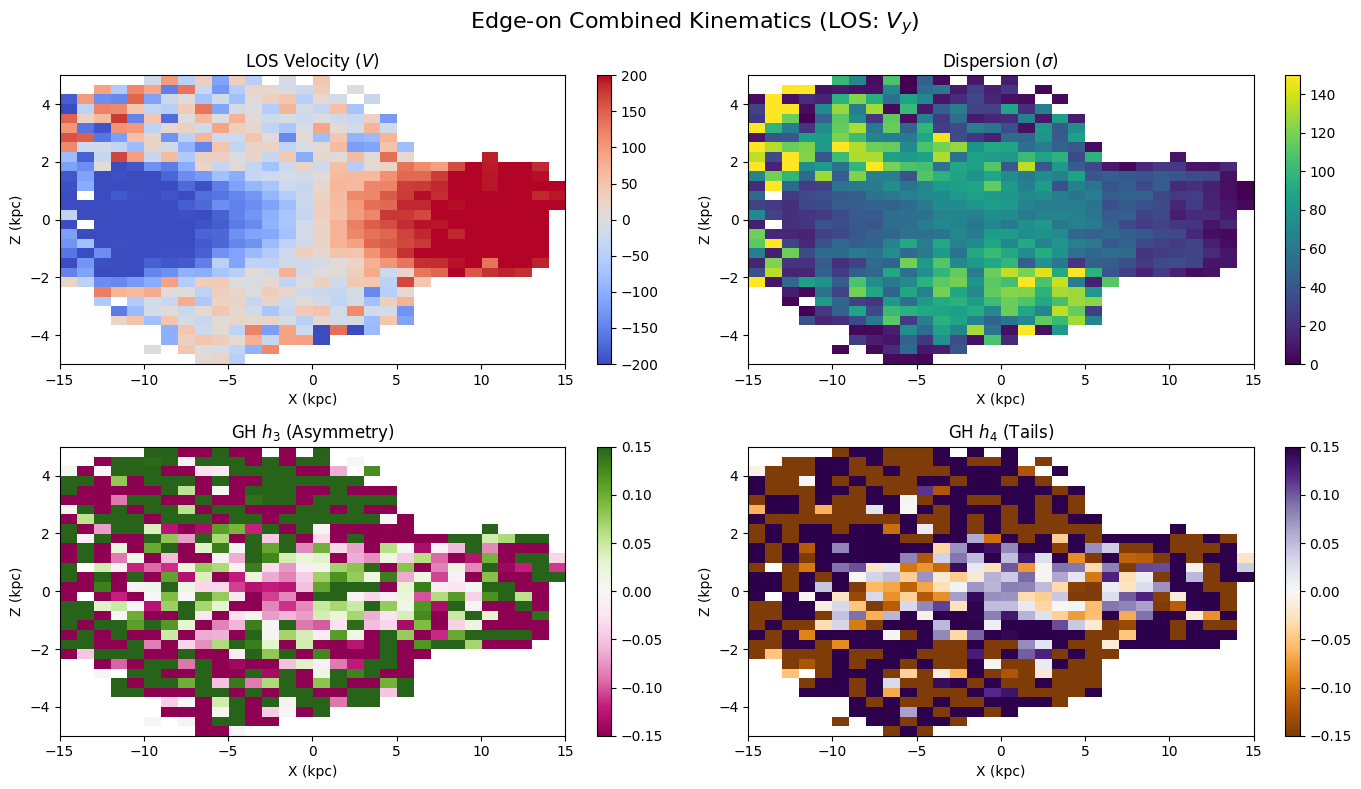

In [26]:
# A. EDGE-ON (XZ Plane | LOS: Y-axis)
print("Computing Edge-On (XZ) maps...")
V_edge, sig_edge, h3_edge, h4_edge = compute_kinematic_maps(
    x, z, vy, all_weights, x_bins, z_bins
)
plot_kinematic_grid(
    V_edge, sig_edge, h3_edge, h4_edge, 
    extent=[x_bins[0], x_bins[-1], z_bins[0], z_bins[-1]], 
    xlabel='X (kpc)', ylabel='Z (kpc)', title='Edge-on Combined Kinematics (LOS: $V_y$)', 
    v_range=200, sig_range=150
)

Computing Face-On (XY) maps...


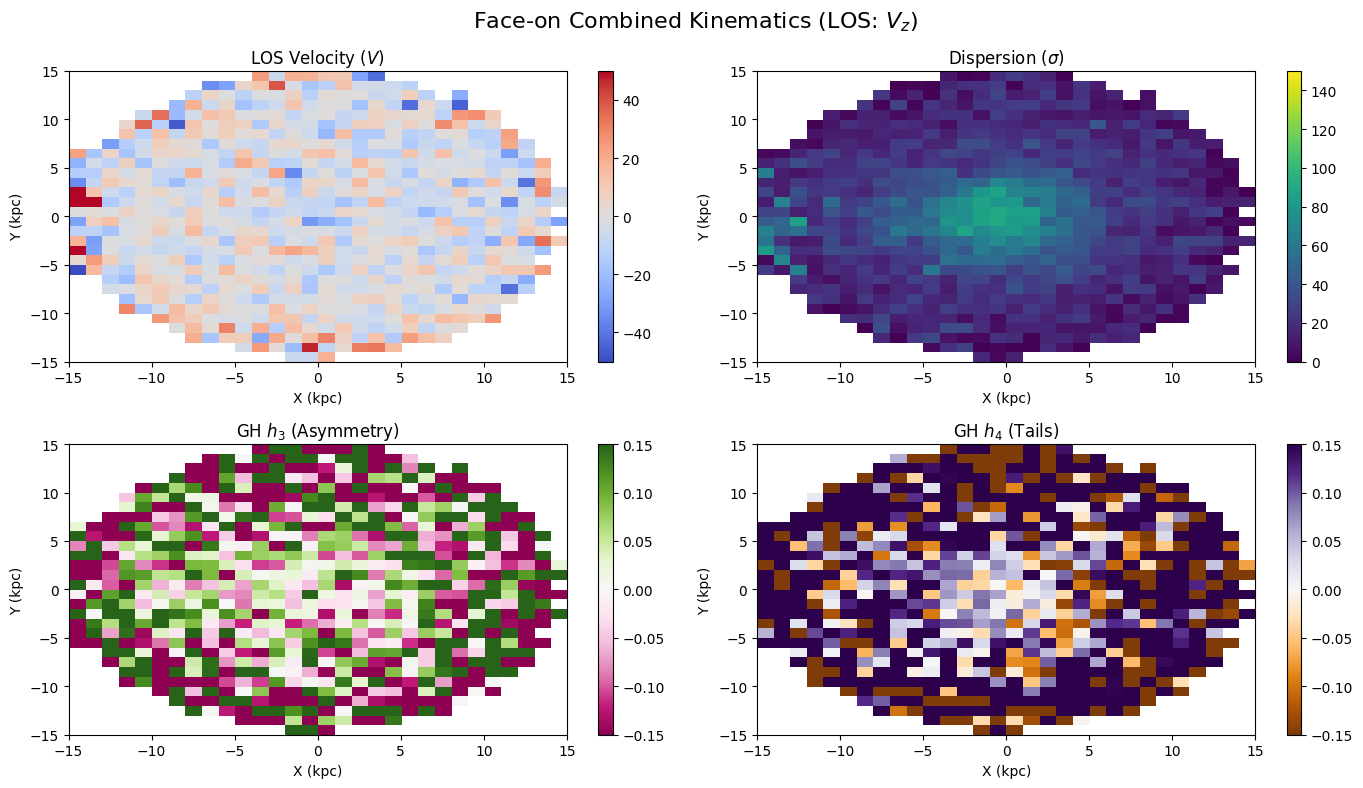

In [27]:
# B. FACE-ON (XY Plane | LOS: Z-axis)
print("Computing Face-On (XY) maps...")
V_face, sig_face, h3_face, h4_face = compute_kinematic_maps(
    x, y, vz, all_weights, x_bins, y_bins
)
plot_kinematic_grid(
    V_face, sig_face, h3_face, h4_face, 
    extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]], 
    xlabel='X (kpc)', ylabel='Y (kpc)', title='Face-on Combined Kinematics (LOS: $V_z$)', 
    v_range=50, sig_range=150
)

Computing Edge-On (YZ) maps...


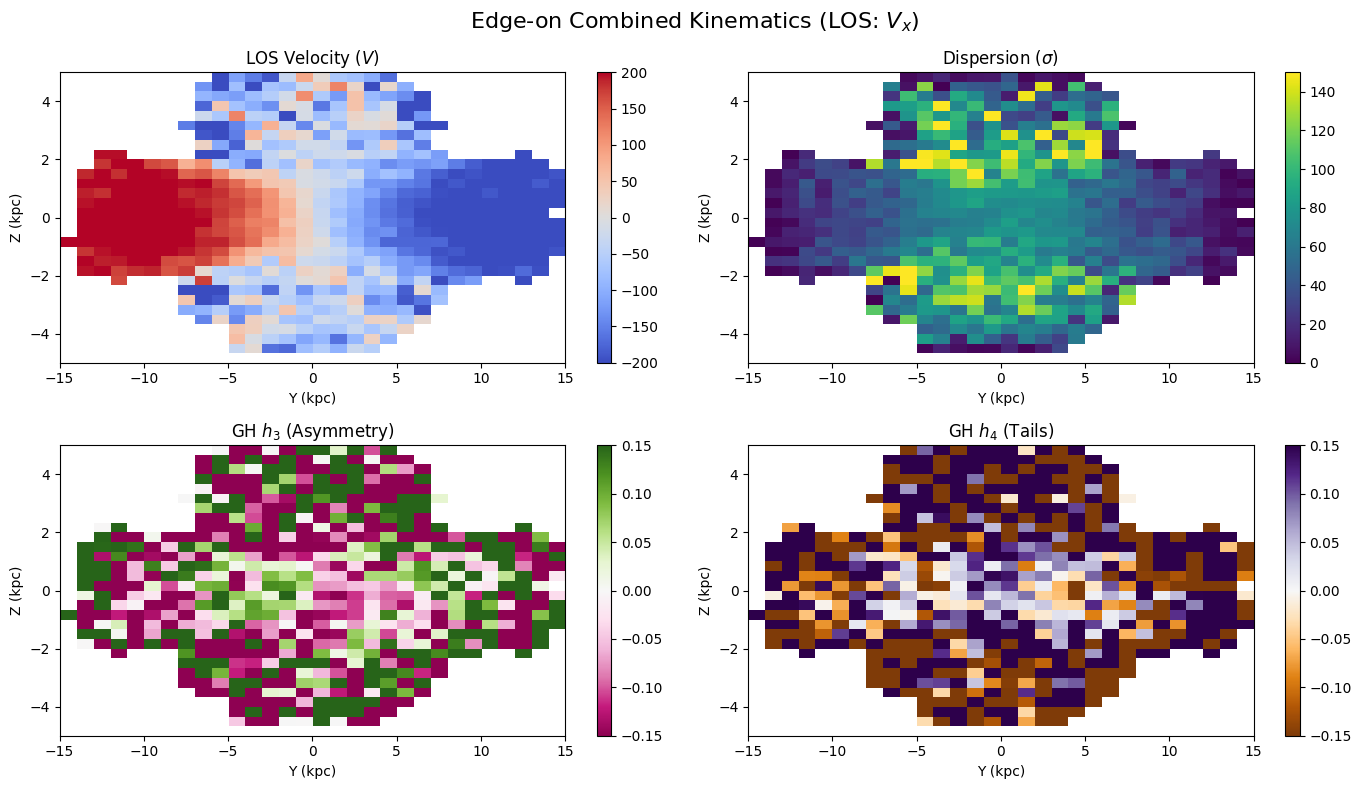

In [28]:
# C. EDGE-ON (YZ Plane | LOS: X-axis)
print("Computing Edge-On (YZ) maps...")
V_yz, sig_yz, h3_yz, h4_yz = compute_kinematic_maps(
    y, z, vx, all_weights, y_bins, z_bins
)
plot_kinematic_grid(
    V_yz, sig_yz, h3_yz, h4_yz, 
    extent=[y_bins[0], y_bins[-1], z_bins[0], z_bins[-1]], 
    xlabel='Y (kpc)', ylabel='Z (kpc)', title='Edge-on Combined Kinematics (LOS: $V_x$)', 
    v_range=200, sig_range=150
)